In [1]:
import scipy as sp
#from scipy.misc import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, factorial
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, einsum, tan, log10
import torch
import warnings
warnings.filterwarnings("ignore")
from utils import h_z_cpa, h_z_cpa_numerator, e_z_cpa, e_z_cpa_numerator, hl2_prime, hl1_prime, hbar, c, alpha, graphene_conductivity
tau = 6.4*1e-13 # scattering time in seconds

In [2]:
M = 1000
epsilon = 1.6
x_1 = 500
x_2 = 504
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [3]:
l = 7
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])

In [4]:
sigmas = prefac * np.einsum("ijk, jk -> ik", mat, vec)

In [5]:
#asymptotic_denom = (-1)**l+1j*exp(2*1j*y)
#asymptotic_num = (-1)**l*(1-m)+1j*(m+1)*exp(2*1j*y)
#sigmas_asymptotic = asymptotic_num/asymptotic_denom 
sigmas_asymptotic = 1 + 1j*m*tan(y-(l-1/2)*pi/2)

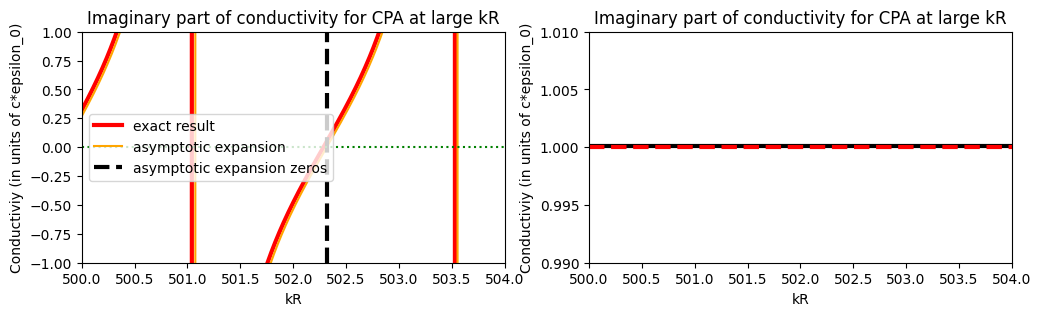

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax1.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansion")
ax1.set_ylim(-1, 1)
ax1.vlines([pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax1.set_xlim(x_1, x_2);
ax1.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax1.set_xlabel("kR")
ax1.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax1.set_title("Imaginary part of conductivity for CPA at large kR");
ax1.legend();

ax2.plot(x, sigmas[0, :], color="black", linewidth=3)
ax2.plot(x, sigmas_asymptotic.real, color="red", linewidth=3, linestyle="dashed")

ax2.set_xlim(x_1, x_2);
ax2.set_ylim(0.99, 1.01)
ax2.set_xlabel("kR")
ax2.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax2.set_title("Imaginary part of conductivity for CPA at large kR");

### We verify that the above indeed corresponds to CPA

In [7]:
s_sqrds = abs(h_z_cpa(l, x, 1.6, -1j*(sigmas[0, :] + 1j*sigmas[1, :])))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  7.412442001093254e-26


### Now we look at subwavelength for the modes with $E_z=0$

In [8]:
M = 1000
epsilon = 1
x = linspace(0.01, 1, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [9]:
ls = np.array([1, 2, 3])
sigma_real_l = np.zeros((len(ls), len(x)))
sigma_imaginary_l = np.zeros((len(ls), len(x)))
quasistatic_dispersion_l = np.zeros((len(ls), len(x)))
real_conductivity_small_k_l = np.zeros((len(ls), len(x)))

for (l_idx, l) in enumerate(ls):
    j_y = jv(l, y); j_x = jv(l, x);
    y_x = yv(l, x); 
    
    j_yprime = jvp(l, y);
    j_xprime = jvp(l, x);
    
    y_xprime = yvp(l, x)
    
    prefac = 1/(j_yprime*(j_xprime**2+y_xprime**2))
    mat = np.array([[y_xprime, j_xprime], [-j_xprime, y_xprime]])
    vec = np.array([j_x*j_yprime-m*j_xprime*j_y, m*j_y*y_xprime-y_x*j_yprime])
    
    sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
    sigma_real = sigmas[0, :]
    sigma_imaginary = sigmas[1, :]
    quasistatic_dispersion = (1+epsilon)*x/l

    sigma_real_l[l_idx, :] = sigma_real
    sigma_imaginary_l[l_idx, :] = sigma_imaginary
    quasistatic_dispersion_l[l_idx, :] = quasistatic_dispersion

    real_conductivity_small_k = pi*(x**(2*l+1))/(factorial(l-1)*factorial(l)*l*2**(2*l-1))
    real_conductivity_small_k_l[l_idx, :] = real_conductivity_small_k

### We again verify that the obtained conductivities correspond to CPA

In [10]:
for (l_idx, l) in enumerate(ls):
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    s_sqrds = abs(h_z_cpa(l, x, epsilon, -1j*(sigma_real + 1j*sigma_imaginary)))**2
    tm_numerator = abs(h_z_cpa_numerator(l, x, epsilon, -1j*(sigma_real + 1j*sigma_imaginary)))
    print("Maximum value for |s|^2: ", s_sqrds.max())
    print("Maximum (absolute) value for the cpa numerator", tm_numerator.max())

Maximum value for |s|^2:  1.775299295972512e-24
Maximum (absolute) value for the cpa numerator 1.4647422929199964e-14
Maximum value for |s|^2:  1.3897729244814232e-14
Maximum (absolute) value for the cpa numerator 1.473583282170099e-14
Maximum value for |s|^2:  8.960573294358833e-05
Maximum (absolute) value for the cpa numerator 1.444794073657868e-14


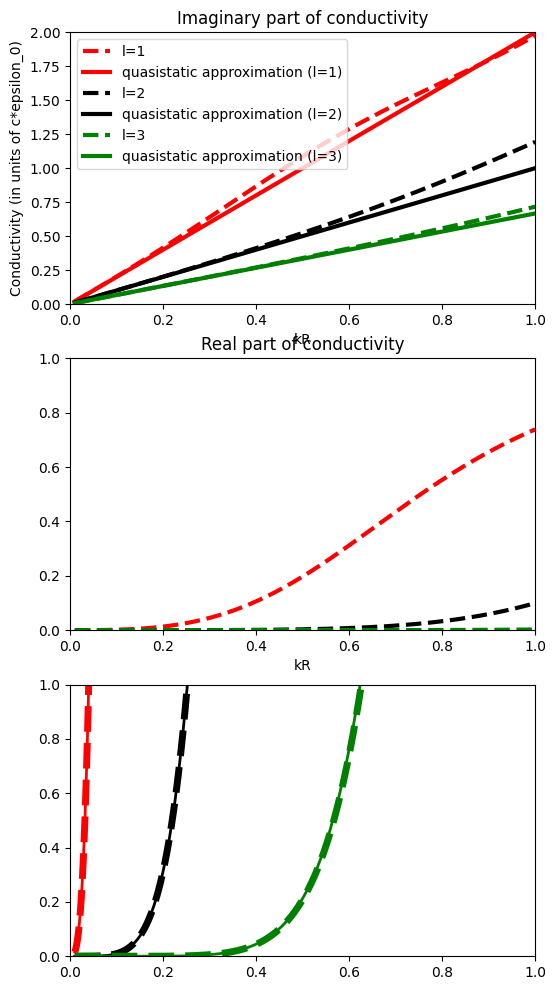

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 12))
l_colors = ["red", "black", "green"]
for (l_idx, l) in enumerate(ls):
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    quasistatic_dispersion = quasistatic_dispersion_l[l_idx]
    real_conductivity_small_k = real_conductivity_small_k_l[l_idx]

    ax1.plot(x, sigma_imaginary, label=f"l={l}", color=l_colors[l_idx],  linestyle="dashed", linewidth=3)
    ax1.plot(x, quasistatic_dispersion, label=f"quasistatic approximation (l={l})", color=l_colors[l_idx], linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 2)
    ax1.set_title("Imaginary part of conductivity")
    ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
    ax1.set_xlabel("kR");
    ax1.legend();
    
    ax2.plot(x, sigma_real, label="exact result", color=l_colors[l_idx], linestyle="dashed", linewidth=3)
    ax2.set_ylim(0, 1)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("kR");
    ax2.set_title("Real part of conductivity");

    ax3.plot(x, real_conductivity_small_k*10**4, label=f"Small k l={l}", color=l_colors[l_idx], linestyle="solid", linewidth=2)    
    ax3.plot(x, sigma_real*10**4, label=f"l={l}", color=l_colors[l_idx], linestyle="dashed", linewidth=5)  
    ax3.set_ylim(0, 1)
    ax3.set_xlim(0, 1)
#plt.savefig("./paper/closed_form_cpa_solution_tm.pdf")

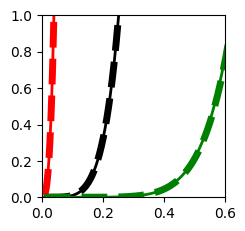

In [13]:
cm = 1/2.54
fig, ax = plt.subplots(figsize=(6*cm, 6*cm))
l_colors = ["red", "black", "green"]
for (l_idx, l) in enumerate(ls):
    sigma_real = sigma_real_l[l_idx]
    real_conductivity_small_k = real_conductivity_small_k_l[l_idx]
    ax.plot(x, real_conductivity_small_k*10**4, label=f"Small k l={l}", color=l_colors[l_idx], linestyle="solid", linewidth=2)    
    ax.plot(x, sigma_real*10**4, label=f"l={l}", color=l_colors[l_idx], linestyle="dashed", linewidth=5)  
ax.set_ylim(0, 1)
ax.set_xlim(0, 0.6);
#plt.savefig("./paper/real_sigma_approximation_tm.pdf")

### Now we find the physical parameters for graphene corresponding to the above

In [14]:
l_idx = 0; # Look at dipole mode
sigma_imaginary = sigma_imaginary_l[l_idx]
sigma_real = sigma_real_l[l_idx]

E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha; # Fermi energies at each kR
a = c*tau*x*sigma_real/sigma_imaginary; # Radii of the cylinders at each kR
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau) # frequencies (in energy units) at each kR

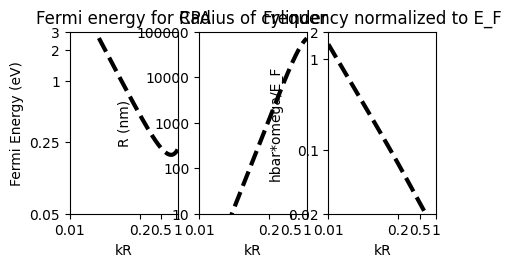

In [15]:
cm = 1/2.54
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12*cm, 6*cm))
ax1.plot(log10(x), log10(E_F), color="black", linestyle="dashed", linewidth=3)
ax1.set_yticks([log10(0.05), log10(0.25), log10(1), log10(2), log10(3)], [0.05, 0.25, 1, 2, 3])
ax1.set_ylim(log10(0.05), log10(3));
ax1.set_xlim(log10(0.01), log10(1))
ax1.set_xticks([log10(0.01), log10(0.2), log10(0.5), log10(1)], [0.01, 0.2, 0.5, 1])
ax2.set_xticks([log10(0.01), log10(0.2), log10(0.5), log10(1)], [0.01, 0.2, 0.5, 1])
ax3.set_xticks([log10(0.01), log10(0.2), log10(0.5), log10(1)], [0.01, 0.2, 0.5, 1])

ax1.set_xlabel("kR");
ax1.set_ylabel("Fermi Energy (eV)");
ax1.set_title("Fermi energy for CPA");

ax2.plot(log10(x), log10(a), color="black", linestyle="dashed", linewidth=3)
ax2.set_yticks([log10(1e1), log10(1e2), log10(1e3), log10(1e4), log10(1e5)], [10, 100, 1000, 10000, 100000])
ax2.set_ylim(log10(10), log10(1e5));
ax2.set_xlim(log10(0.01), log10(1))
ax2.set_xlabel("kR");
ax2.set_ylabel("R (nm)");
ax2.set_title("Radius of cylinder");

ax3.plot(log10(x), log10(hbar_omega/E_F), color="black", linestyle="dashed", linewidth=3)
ax3.set_yticks([log10(0.02), log10(0.01), log10(0.1), log10(1), log10(2)], [0.02, 0.01, 0.1, 1, 2])
ax3.set_ylim(log10(0.02), log10(2));
ax3.set_xlim(log10(0.01), log10(1))
ax3.set_xlabel("kR");
ax3.set_ylabel("hbar*omega/E_F");
ax3.set_title("Frequency normalized to E_F");
#plt.savefig("./paper/cpa_cylinder_parameters.pdf");

### We find the slopes corresponding to the above (to see the scaling with respect to the normalized wavelength)

In [26]:
slope_R = (np.diff(log10(a))/np.diff(log10(x)))[0]
slope_omega = (np.diff(log10(hbar_omega))/np.diff(log10(x)))[0]
print("Scaling power for radius: ", slope_R )
print("Scaling power for frequency: ", slope_omega)

Scaling power for radius:  3.000321717746245
Scaling power for frequency:  -2.000321717746245


### We verify that graphene gives the correct conductivity at those Fermi energies and frequencies

In [16]:
omega = c*x/a
graphene_cpa_sigmas = graphene_conductivity(E_F, omega*hbar, hbar/tau, include_interband=False)
print("Maximum deviation from CPA conductivity (in normalized absolute value): ", abs((graphene_cpa_sigmas - sigma_real - 1j*sigma_imaginary)/graphene_cpa_sigmas).max())

Maximum deviation from CPA conductivity (in normalized absolute value):  6.219860788623386e-16


### Now we find the bandwidth for CPA

In [28]:
M = 10000
omega_range = linspace(1, 20, M)*1e12 # frequency in Hertz 
idxs = [500, 600, 700, 800, 900]
#idxs = [100, 200, 300, 400, 500]
sqrds = zeros((len(idxs), M))
for (sq_idx, idx) in enumerate(idxs):
    x_range = omega_range * a[idx]/c # keep radius fixed
    sigma_range = graphene_conductivity(E_F[idx], omega_range*hbar, hbar/tau, include_interband=False) # Graphene conductivity over the frequency range
    g_omega_range = -1j*sigma_range
    sqrds[sq_idx, :] = abs(h_z_cpa(1, x_range, epsilon, g_omega_range))**2

In [29]:
print("Minimum |s|^2: ", sqrds.min((1)))

Minimum |s|^2:  [1.23625626e-07 2.17692060e-07 1.31237756e-07 2.42993133e-07
 2.41764057e-07]


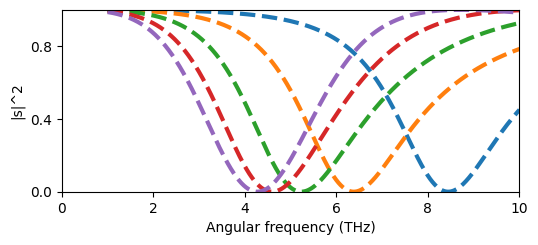

In [30]:
cm = 1/2.54
fig, ax = plt.subplots(figsize=(15*cm, 6*cm))
for (sq_idx, idx) in enumerate(idxs):
    ax.plot(omega_range/1e12, sqrds[sq_idx], linestyle="dashed", linewidth=3, label=f"a={round(a[idx]/1e3)} microns, E_F={round(E_F[idx]*1e3)} meV, omega={round(omega[idx]/1e12, 3)} s^-1, x={round(x[idx], 2)}")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.4, 0.8])
ax.set_xlim(0, 10);
ax.set_xlabel("Angular frequency (THz)");
ax.set_ylabel("|s|^2");
#ax.legend();
#plt.savefig("./paper/cpa_bandwidth_cylinder.pdf")

### Now we do the same for the radiative ($E=E_z$) modes. First, we look at large $kR$

In [23]:
M = 1000
epsilon = 4
x = linspace(100, 110, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [24]:
l = 5
j_y = jv(l, y); j_x = jv(l, x);

y_x = yv(l, x); 

j_yprime = jvp(l, y);
j_xprime = jvp(l, x);

y_xprime = yvp(l, x)

prefac = 1/(j_y*(j_x**2+y_x**2))
mat = np.array([[y_x, j_x], [-j_x, y_x]])
vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])

sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)

asymptotic_denom = (-1)**(l+1)+1j*exp(2*1j*y)
asymptotic_num = (-1)**(l+1)*(1-m)+1j*(m+1)*exp(2*1j*y)
#sigmas_asymptotic = asymptotic_num/asymptotic_denom 
sigmas_asymptotic = 1 + 1j*m*tan(y-(l-1/2)*pi/2)

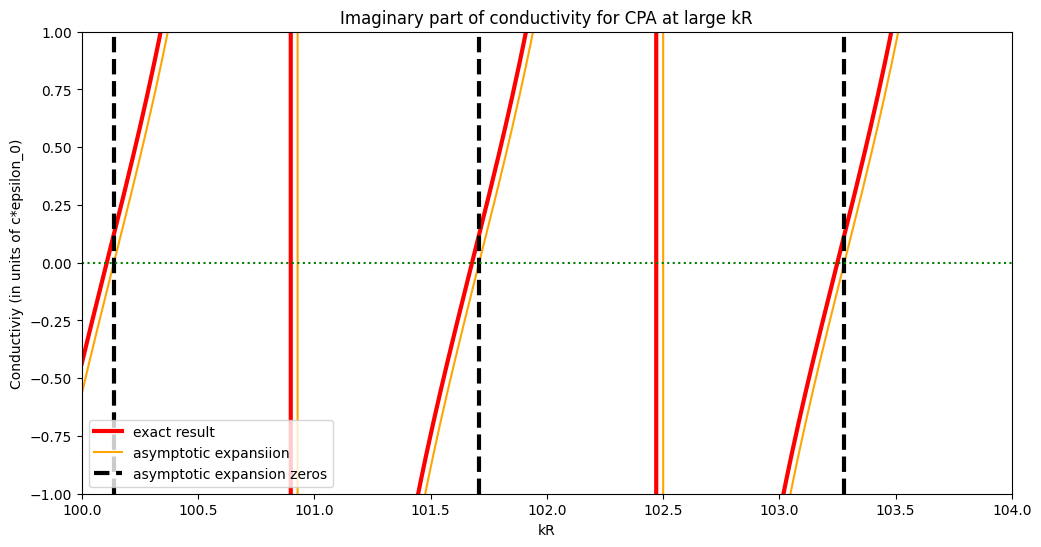

In [25]:
x_1 = 100
x_2 = 104
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.plot(x, sigmas[1, :], color="red", linewidth=3, label="exact result")
ax.plot(x, sigmas_asymptotic.imag, color="orange", label="asymptotic expansiion")
ax.set_ylim(-1, 1)
ax.vlines([-pi/4/m]+ pi * linspace(1, 1000, 1000)/m, -1, 1, color="black", linestyle="dashed", linewidth=3, label="asymptotic expansion zeros")
ax.hlines([0], x_1, x_2, linestyle="dotted", color="green")
ax.set_xlim(x_1, x_2);
ax.set_xlabel("kR")
ax.set_ylabel("Conductiviy (in units of c*epsilon_0)");
ax.set_title("Imaginary part of conductivity for CPA at large kR");
ax.legend();

### We check that the above corresponds to CPA

In [26]:
s_sqrds = abs(e_z_cpa(l, x, epsilon, -1j*(sigmas[0, :] + 1j*sigmas[1, :])))**2
print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  3.176657832385365e-26


### Now we look at subwavelength ($kR<1$) for the $H_z=0$ modes

In [31]:
M = 1000
epsilon = 1
x_1 = 0.01
x_2 = 0.5
x = linspace(x_1, x_2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

In [40]:
ls = np.array([1, 2, 3])
sigma_real_l = np.zeros((len(ls), len(x)))
sigma_imaginary_l = np.zeros((len(ls), len(x)))
small_cylinder_dispersion_l = np.zeros((len(ls), len(x)))
real_conductivity_small_k_l = np.zeros((len(ls), len(x)))

for (l_idx, l) in enumerate(ls):
    j_y = jv(l, y); j_x = jv(l, x);
    
    y_x = yv(l, x); 
    
    j_yprime = jvp(l, y);
    j_xprime = jvp(l, x);
    
    y_xprime = yvp(l, x)
    
    prefac = 1/(j_y*(j_x**2+y_x**2))
    mat = np.array([[y_x, j_x], [-j_x, y_x]])
    vec = np.array([m*j_x*j_yprime-j_xprime*j_y, j_y*y_xprime-m*y_x*j_yprime])
    sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
    sigma_real = sigmas[0, :]
    sigma_imaginary = sigmas[1, :]
    small_cylinder_dispersion = -(2*l)/x
    sigma_real_l[l_idx, :] = sigma_real
    sigma_imaginary_l[l_idx, :] = sigma_imaginary
    small_cylinder_dispersion_l[l_idx, :] = small_cylinder_dispersion

    real_conductivity_small_k = pi*(x**(2*l-1)*l)/(factorial(l-1)*factorial(l)*2**(2*l-1))
    real_conductivity_small_k_l[l_idx, :] = real_conductivity_small_k

### We again verify that the above conductivities give us CPA

In [41]:
for (l_idx, l) in enumerate(ls):
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    s_sqrds = abs(e_z_cpa(l, x, 1, -1j*(sigma_real + 1j*sigma_imaginary)))**2
    print("Maximum value for |s|^2: ", s_sqrds.max())

Maximum value for |s|^2:  8.800955909478716e-25
Maximum value for |s|^2:  1.4035661979652516e-14
Maximum value for |s|^2:  0.00023851439475677718


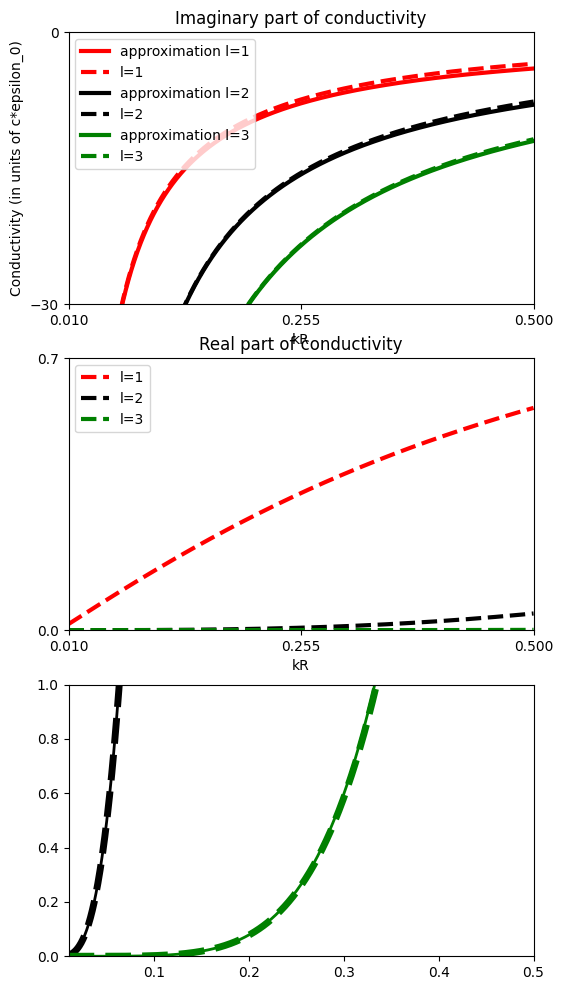

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 12))
l_colors = ["red", "black", "green"]
for (l_idx, l) in enumerate(ls):
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    small_cylinder_dispersion = small_cylinder_dispersion_l[l_idx]
    real_conductivity_small_k = real_conductivity_small_k_l[l_idx]

    ax1.plot(x, small_cylinder_dispersion, label=f"approximation l={l}", color=l_colors[l_idx], linestyle="solid", linewidth=3)#ax1.set_ylim(0, 2)
    ax1.plot(x, sigma_imaginary, label=f"l={l}", color=l_colors[l_idx], linestyle="dashed", linewidth=3)
    ax1.set_xlim(x_1, x_2)
    ax1.set_title("Imaginary part of conductivity")
    ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
    ax1.set_xlabel("kR");
    ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
    ax1.legend();
    
    ax2.plot(x, sigma_real, label=f"l={l}", color=l_colors[l_idx], linestyle="dashed", linewidth=3)
    #ax2.fill([x_1, x_1, x_2, x_2], [alpha, 2*alpha, 2*alpha, alpha], color="grey", alpha=0.1)
    ax2.set_xlim(x_1, x_2)
    ax2.set_yticks([0, 0.7])
    ax1.set_ylim(-30, 0)
    ax1.set_yticks([-30, 0])
    ax2.set_xlabel("kR");
    ax2.set_title("Real part of conductivity");
    #ax2.hlines([alpha], x_1, x_2, label="Maximum conductivity possible", color="orange")
    ax2.set_xticks([x_1, (x_1+x_2)/2, x_2]);
    ax2.set_ylim(0, 0.7)
    #ax2.set_ylim(sigma_real.min(), sigma_real.max())
    ax2.legend();
 
    ax3.plot(x, real_conductivity_small_k*10**4, label=f"Small k l={l}", color=l_colors[l_idx], linestyle="solid", linewidth=2)    
    ax3.plot(x, sigma_real*10**4, label=f"l={l}", color=l_colors[l_idx], linestyle="dashed", linewidth=5)  
    ax3.set_ylim(0, 1)
    ax3.set_xlim(x_1, x_2)
#plt.savefig("./paper/closed_form_cpa_solution_te.pdf")

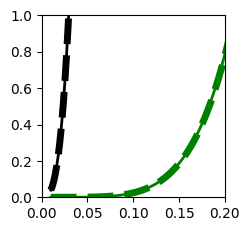

In [43]:
cm = 1/2.54
fig, ax = plt.subplots(figsize=(6*cm, 6*cm))
l_colors = ["red", "black", "green"]
for (l_idx, l) in enumerate(ls):
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]
    small_cylinder_dispersion = small_cylinder_dispersion_l[l_idx]
    real_conductivity_small_k = real_conductivity_small_k_l[l_idx]
 
    ax.plot(x, real_conductivity_small_k*10**5, label=f"Small k l={l}", color=l_colors[l_idx], linestyle="solid", linewidth=2)    
    ax.plot(x, sigma_real*10**5, label=f"l={l}", color=l_colors[l_idx], linestyle="dashed", linewidth=5)  
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 0.2)
plt.savefig("./paper/real_sigma_approximation_te.pdf")

### Now we find the physical parameters for graphene that would give us these conductivities. Notice that we only tune $E_F$ so as to give us the correct real part of the conductivity at $\hbar\omega=2E_F$. The imaginary component will be given by the logarithmic interband contribution (which we do not deal with here).

In [189]:
E_F_1 = (hbar/tau)*(alpha+sqrt(alpha**2-sigma_real**2))/(2*sigma_real);
E_F_2 = (hbar/tau)*(alpha-sqrt(alpha**2-sigma_real**2))/(2*sigma_real);

a_1 = c*x*hbar/(2*E_F_1);
a_2 = c*x*hbar/(2*E_F_2);

### We verify that the above Fermi energies/radii give us the correct conductivities

In [202]:
for (a, E_F) in zip([a_1, a_2], [E_F_1, E_F_2]):
    omega = c*x/a
    graphene_cpa_sigmas = (4*1j*alpha*E_F/(hbar*(omega+1j/tau))).real
    sigma_deviations =  abs((graphene_cpa_sigmas - sigma_real)/graphene_cpa_sigmas)
    sigma_deviations = np.where(np.isnan(sigma_deviations), 0, sigma_deviations)
    print("Maximum deviation from CPA conductivity (in normalized absolute value): ", sigma_deviations.max())


Maximum deviation from CPA conductivity (in normalized absolute value):  6.74036890178645e-16
Maximum deviation from CPA conductivity (in normalized absolute value):  2.6359519721214188e-15


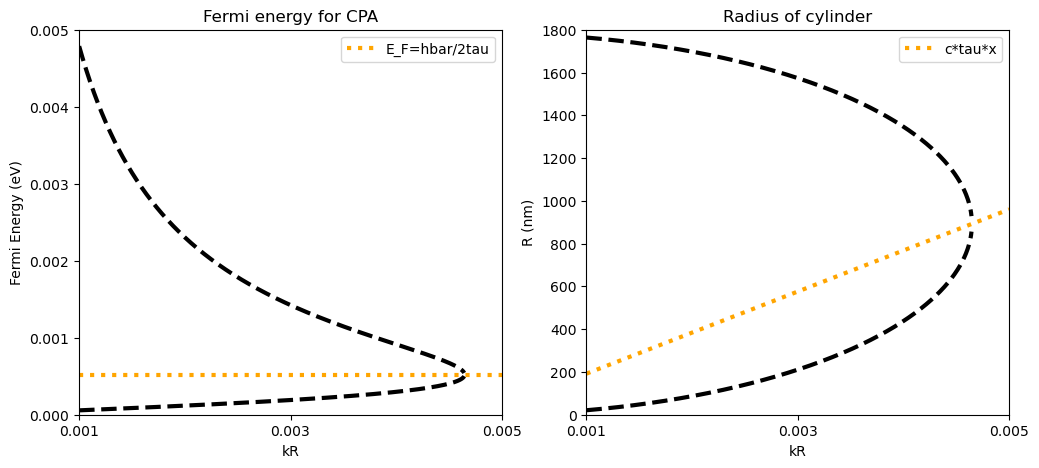

In [201]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(x, E_F_1, color="black", linestyle="dashed", linewidth=3)
ax1.plot(x, E_F_2, color="black", linestyle="dashed", linewidth=3)

ax1.set_xticks([x_1, (x_1+x_2)/2, x_2])
ax1.set_xlim(x_1, x_2)
ax1.set_ylim(0, 0.005)
ax1.set_xlabel("kR");
ax1.set_ylabel("Fermi Energy (eV)");
ax1.hlines([hbar/(2*tau)], x_1, x_2, linestyle="dotted", color="orange", label="E_F=hbar/2tau", linewidth=3)
ax1.legend()
ax1.set_xticks([x_1,(x_1+x_2)/2, x_2])
ax1.set_title("Fermi energy for CPA");

ax2.plot(x, a_1, color="black", linestyle="dashed", linewidth=3)
ax2.plot(x, a_2, color="black", linestyle="dashed", linewidth=3)
ax2.plot(x, c*tau*x, color="orange", linestyle="dotted", linewidth=3, label="c*tau*x")
ax2.set_ylim(0, 1800)
ax2.set_xlim(x_1, x_2)
ax2.set_xticks([x_1,(x_1+x_2)/2, x_2])
ax2.set_xlabel("kR");
ax2.set_ylabel("R (nm)");
ax2.legend()
ax2.set_title("Radius of cylinder");